# P4 — Validation Report

Validate the matched synthetic population against benchmarks, with **side-by-side visuals** and a
**pass/fail summary**. All money is **2017 Rands**. Tolerances are stated per check.

**Benchmarks & honesty note**
- **FinScope 2019** is the *source* of the inclusion flags, so Section B is a **match-fidelity** check
  (reproduction), not independent external validation.
- **Income inequality (Gini)** is a genuinely **external** check — we never targeted it.
- Behavioural targets (default rates, etc.) are **deferred to BNPL providers** (out of scope here).

## 0. Setup, load, benchmarks

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

def find_root(start=Path.cwd()):
    for d in [start, *start.parents]:
        if (d / "data/processed/synthetic_population_matched.parquet").exists():
            return d
    raise FileNotFoundError("run P2 first")
ROOT = find_root()
df = pd.read_parquet(ROOT / "data/processed/synthetic_population_matched.parquet")
QORDER = ["Q1", "Q2", "Q3", "Q4", "Q5"]
df["income_quintile"] = pd.Categorical(df["income_quintile"], QORDER, ordered=True)
flags = ["banked", "credit_access_formal", "informal_finance", "savings_product"]
for f in flags: df[f] = df[f].astype(int)
if "dsti" not in df:
    df["dsti"] = (df["monthly_trad_repayment"] / df["w5_hhincome"].replace(0, np.nan)).fillna(0)
W = df.w5_wgt.values
def wmean(s, w): return np.average(s, weights=w)

# --- benchmarks ---
SA_GINI_BAND = (0.63, 0.70)     # per-capita income Gini, SA (World Bank / Stats SA ~0.65-0.69)
SA_MEAN_HHSIZE = 3.3            # Stats SA ~3.2-3.4 persons/household
results = []   # (check, metric, value, benchmark, tol, pass)

# --- FinScope benchmark (national + by quintile), derived the same way P2 did ---
fs = pd.read_csv(ROOT / "data/raw/FINMARK_2019/Finscope South Africa 2019.csv",
                 usecols=["HH_WEIGHT16","Number_in_HH","M13_MHI_Imputed","F1","G5","K7","G10","G11","G12","G13","G14"])
fs = fs[fs.HH_WEIGHT16 > 0].copy()
MID = {"No Income":0,"R1 - R999":500,"R1 000 - R2 999":2000,"R3 000 - R7 999":5500,
       "R8 000 - R11 999":10000,"R12 000 - R29 999":21000,"R30 000 or more":40000}
fs["pc"] = fs.M13_MHI_Imputed.map(MID) / pd.to_numeric(fs.Number_in_HH, errors="coerce").replace(0, np.nan)
fs = fs.dropna(subset=["pc"])
bounds = [900.0, 1801.42, 3400.0, 7712.14]; edges = [-np.inf] + bounds + [np.inf]
fs["income_quintile"] = pd.cut(fs.pc, edges, labels=QORDER, include_lowest=True)
FORMAL = ["Bank","Retail store (e.g. Woolworths, Edgars etc)","Micro finance institution e.g. Wonga","Insurance company"]
fs["banked"] = (fs.F1 == "Yes").astype(int)
fs["credit_access_formal"] = (fs.G5.isin(FORMAL) | (fs[["G10","G11","G12","G13","G14"]] == "Yes").any(axis=1)).astype(int)
fs["savings_product"] = fs.K7.astype(str).str.strip().str.startswith("R").astype(int)
fs["informal_finance"] = fs.G5.isin(["Mashonisa or loan shark",
    "Stokvel society, burial society, umgalelo or savings club","Friends or family or household member",
    "Colleagues or neighbours","Employer including getting an advance on your salary"]).astype(int)
print("loaded:", len(df), "synthetic |", len(fs), "FinScope donors")

loaded: 10841 synthetic | 4969 FinScope donors


## A. Internal consistency (vs NIDS source)

The matched population is the full weighted NIDS W5 sample, so income marginals equal the NIDS source
by construction (this becomes a real test after the P3 resample). Here we check the quintile balance,
mean household size, and absence of impossible values.

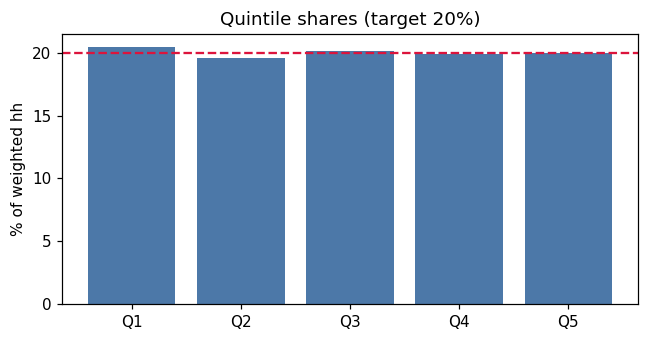

mean hh size: 3.03 (benchmark ~3.3) | impossible values: 0


In [2]:
shares = df.groupby("income_quintile", observed=True).apply(lambda d: d.w5_wgt.sum()) / df.w5_wgt.sum()
ok_shares = bool((shares.sub(0.20).abs() <= 0.02).all())
mean_size = wmean(df.w5_hhsizer, W)
ok_size = abs(mean_size - SA_MEAN_HHSIZE) <= 0.5
neg = int((df.liquid_savings < 0).sum() + (df.D_trad < 0).sum() + (df.expenditure_discretionary < 0).sum())

results += [("A. quintile shares ≈20%", "max |share-0.20|", round(shares.sub(0.20).abs().max(), 3), "≤0.02", "±2pp", ok_shares),
            ("A. mean household size", "weighted mean", round(mean_size, 2), f"~{SA_MEAN_HHSIZE}", "±0.5", ok_size),
            ("A. no impossible values", "neg savings/debt/disc", neg, "0", "exact", neg == 0)]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(QORDER, shares.values * 100, color="#4C78A8"); ax.axhline(20, color="crimson", ls="--")
ax.set_ylabel("% of weighted hh"); ax.set_title("Quintile shares (target 20%)"); plt.tight_layout(); plt.show()
print("mean hh size:", round(mean_size, 2), "(benchmark ~3.3) | impossible values:", neg)

## B. FinScope match fidelity (vs FinScope)

Do the imported flags reproduce FinScope's rates — **nationally and within each quintile**?

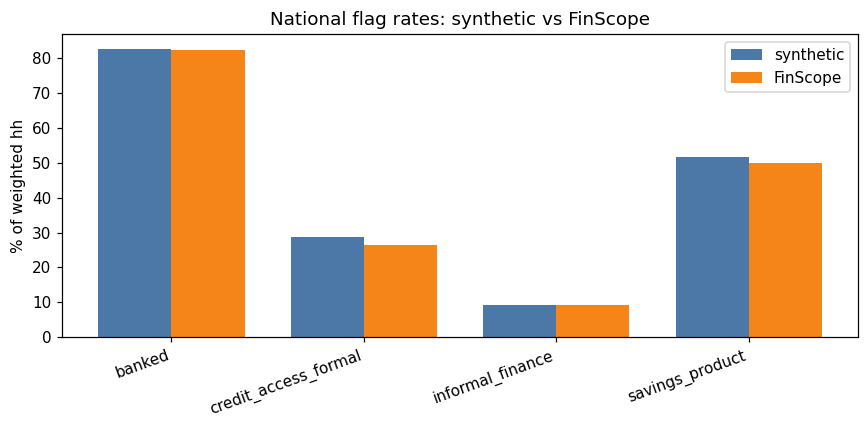

,synthetic,finscope,diff_pp
banked,82.8,82.4,0.4
credit_access_formal,28.7,26.4,2.3
informal_finance,9.2,9.1,0.1
savings_product,51.8,49.9,1.8


In [3]:
nat = pd.DataFrame({
    "synthetic": {f: wmean(df[f], W) * 100 for f in flags},
    "finscope":  {f: np.average(fs[f], weights=fs.HH_WEIGHT16) * 100 for f in flags}})
nat["diff_pp"] = (nat.synthetic - nat.finscope).round(1)
nat = nat.round(1)
for f in flags:
    ok = abs(nat.loc[f, "diff_pp"]) <= 3.0
    results.append((f"B. {f} (national)", "synthetic−finscope", nat.loc[f, "diff_pp"], "0", "±3pp", ok))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(flags)); w = 0.38
ax.bar(x - w/2, nat.synthetic, w, label="synthetic", color="#4C78A8")
ax.bar(x + w/2, nat.finscope, w, label="FinScope", color="#F58518")
ax.set_xticks(x); ax.set_xticklabels(flags, rotation=20, ha="right")
ax.set_ylabel("% of weighted hh"); ax.set_title("National flag rates: synthetic vs FinScope"); ax.legend()
plt.tight_layout(); plt.show()
nat

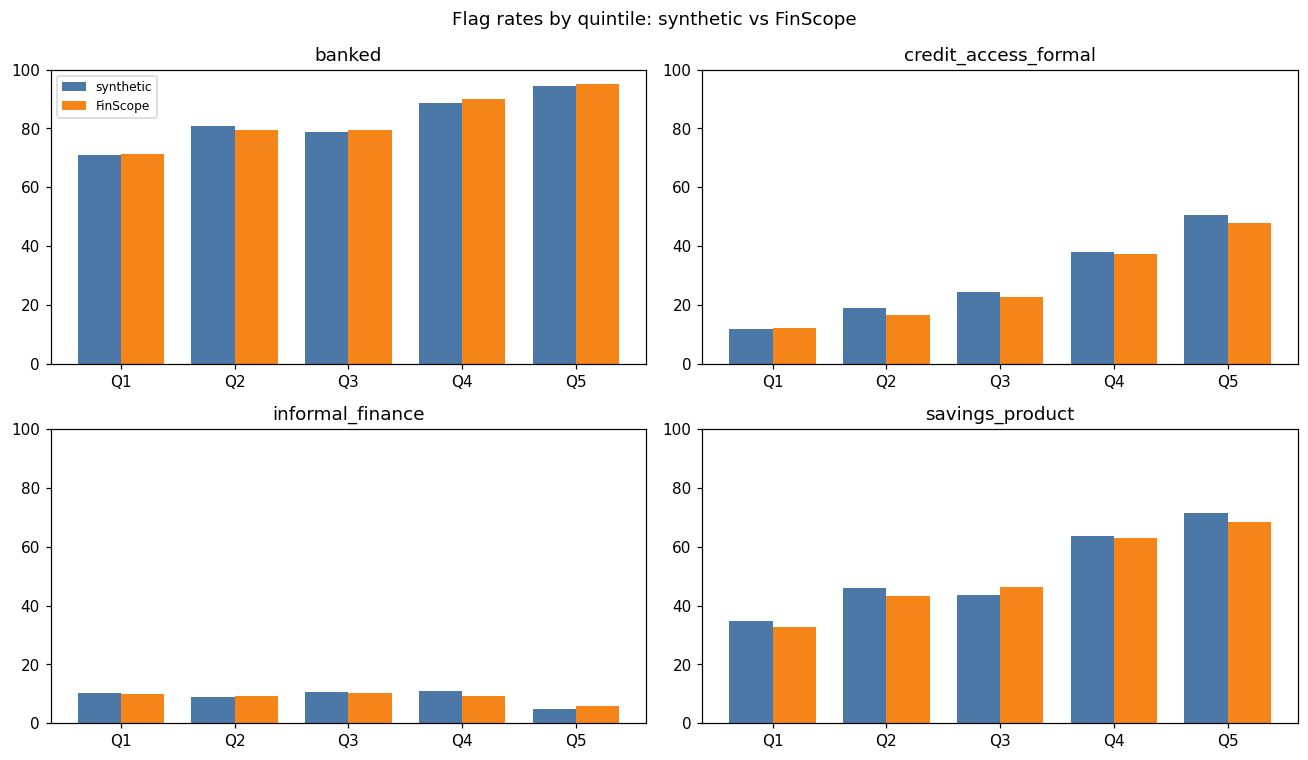

worst by-quintile gap: 3.0 pp


In [4]:
# by-quintile: synthetic vs FinScope, one panel per flag
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
worst = 0.0
for ax, f in zip(axes.ravel(), flags):
    syn = df.groupby("income_quintile", observed=True).apply(lambda d: wmean(d[f], d.w5_wgt) * 100)
    fsr = fs.groupby("income_quintile", observed=True).apply(lambda d: np.average(d[f], weights=d.HH_WEIGHT16) * 100)
    worst = max(worst, (syn - fsr).abs().max())
    x = np.arange(len(QORDER)); wdt = 0.38
    ax.bar(x - wdt/2, syn.values, wdt, label="synthetic", color="#4C78A8")
    ax.bar(x + wdt/2, fsr.reindex(QORDER).values, wdt, label="FinScope", color="#F58518")
    ax.set_xticks(x); ax.set_xticklabels(QORDER); ax.set_title(f); ax.set_ylim(0, 100)
axes[0, 0].legend(fontsize=8); fig.suptitle("Flag rates by quintile: synthetic vs FinScope"); plt.tight_layout(); plt.show()
results.append(("B. by-quintile flags", "max |diff| across all q×flag", round(worst, 1), "0", "±5pp", worst <= 5.0))
print("worst by-quintile gap:", round(worst, 1), "pp")

## C. Income inequality (external benchmark)

Weighted Gini of per-capita income vs the SA benchmark band — a check we never optimized for, plus a
Lorenz curve.

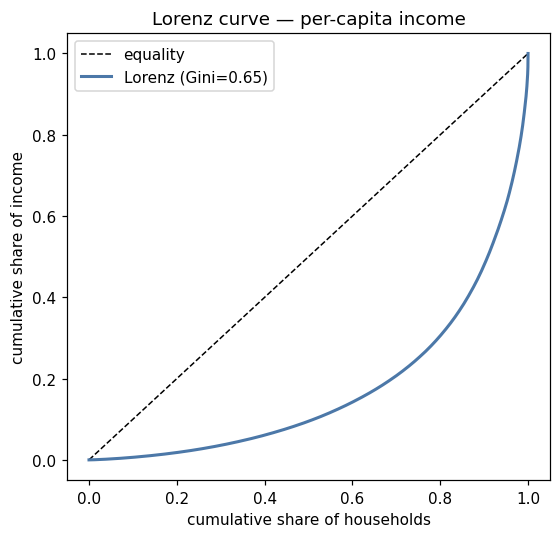

Gini per-capita 0.651 | hh 0.611 | SA benchmark (0.63, 0.7)


In [5]:
def wgini(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float); o = np.argsort(x); x, w = x[o], w[o]
    cw = np.cumsum(w); cxw = np.cumsum(x * w)
    return 1 - np.sum((cxw[1:] + cxw[:-1]) * np.diff(cw)) / (cxw[-1] * cw[-1])

g_pc = wgini(df.income_pc, W); g_hh = wgini(df.w5_hhincome, W)
ok_gini = SA_GINI_BAND[0] <= g_pc <= SA_GINI_BAND[1]
results.append(("C. per-capita income Gini", "weighted Gini", round(g_pc, 3), f"{SA_GINI_BAND}", "in band", ok_gini))

o = np.argsort(df.income_pc.values); x = df.income_pc.values[o]; w = W[o]
cum_p = np.cumsum(w) / w.sum(); cum_i = np.cumsum(x * w) / (x * w).sum()
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="equality")
ax.plot(np.r_[0, cum_p], np.r_[0, cum_i], color="#4C78A8", lw=2, label=f"Lorenz (Gini={g_pc:.2f})")
ax.set_xlabel("cumulative share of households"); ax.set_ylabel("cumulative share of income")
ax.set_title("Lorenz curve — per-capita income"); ax.legend(); plt.tight_layout(); plt.show()
print(f"Gini per-capita {g_pc:.3f} | hh {g_hh:.3f} | SA benchmark {SA_GINI_BAND}")

## D. Servicing & DSTI plausibility (post-fix)

After the term-floor + affordability-cap fix, debt-service-to-income should be bounded and
right-shaped. Benchmark is qualitative (NCR: credit-active DSTI typically ~20–40%, few extreme).

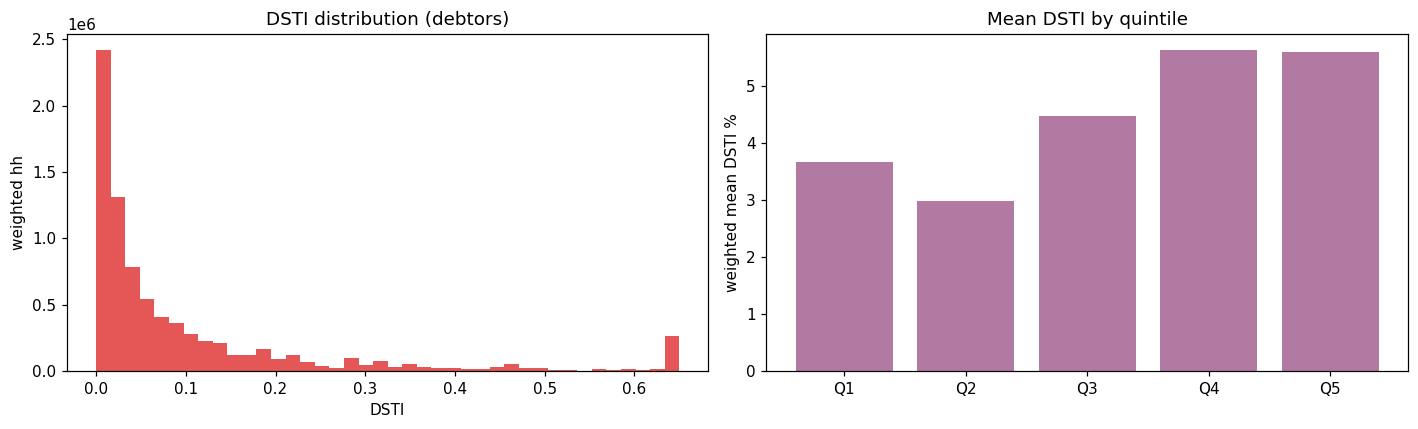

max DSTI: 0.65 | repay>income: 0 | DSTI>0.5: 153 | share of debtors: 4702


In [6]:
dsti = df.dsti
n_over1 = int((df.monthly_trad_repayment > df.w5_hhincome).sum())
ok_dsti = (n_over1 == 0) and (dsti.max() <= 0.66)
results.append(("D. DSTI bounded", "households repay>income", n_over1, "0", "exact", ok_dsti))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
d = df[dsti > 0]
axes[0].hist(d.dsti, bins=40, weights=d.w5_wgt, color="#E45756")
axes[0].set_xlabel("DSTI"); axes[0].set_ylabel("weighted hh"); axes[0].set_title("DSTI distribution (debtors)")
byq = df.groupby("income_quintile", observed=True).apply(lambda x: wmean(x.dsti, x.w5_wgt) * 100)
axes[1].bar(QORDER, byq.values, color="#B279A2"); axes[1].set_ylabel("weighted mean DSTI %")
axes[1].set_title("Mean DSTI by quintile"); plt.tight_layout(); plt.show()
print("max DSTI:", round(dsti.max(), 3), "| repay>income:", n_over1,
      "| DSTI>0.5:", int((dsti > 0.5).sum()), "| share of debtors:", int((df.D_trad > 0).sum()))

## F. Resample fidelity — 5,000 unweighted vs weighted source (live test)

Now that P3 exists, the income-vs-source check is **live**: the unweighted 5,000 agents must reproduce
the *weighted* matched population (quintile shares, flag rates, Gini, and the income ECDF).

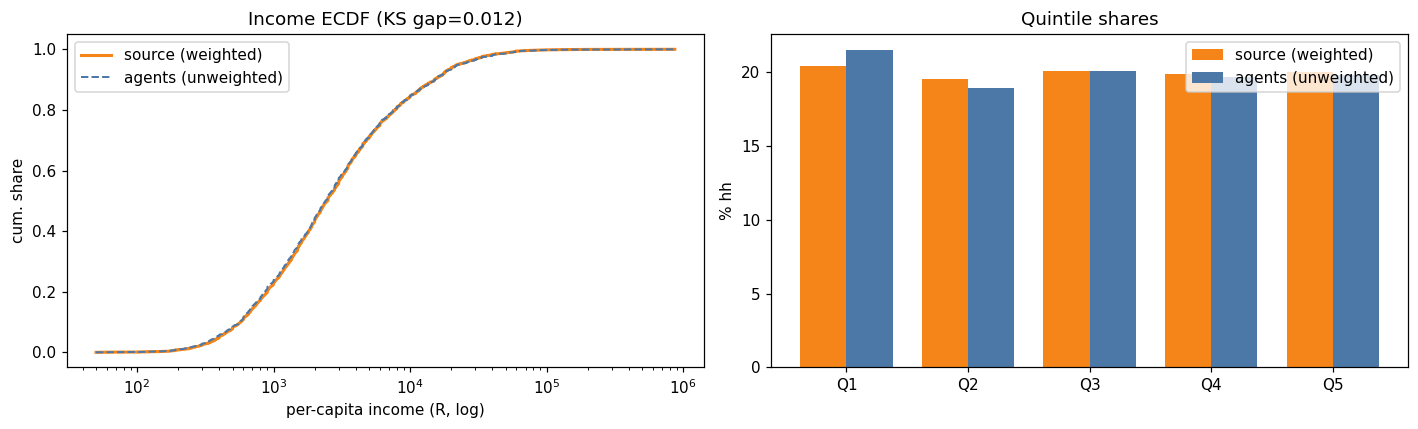

share gap 1.1pp | flag gap 0.3pp | KS 0.012 | Gini agents 0.671 vs source 0.651


In [7]:
agents = pd.read_parquet(ROOT / "data/processed/synthetic_population_5000.parquet")
agents["income_quintile"] = pd.Categorical(agents["income_quintile"], QORDER, ordered=True)
for f in flags: agents[f] = agents[f].astype(int)

# quintile share + flag-rate gaps (unweighted agents vs weighted source)
share_gap = max(abs((agents.income_quintile == q).mean()*100 - wmean((df.income_quintile==q).astype(int), W)*100) for q in QORDER)
flag_gap = max(abs(agents[f].mean()*100 - wmean(df[f], W)*100) for f in flags)
gini_ag = wgini(agents.income_pc, np.ones(len(agents))); gini_src = wgini(df.income_pc, W)
# income ECDF KS gap
xs = np.sort(df.income_pc.values); ws = W[np.argsort(df.income_pc.values)]; Fsrc = np.cumsum(ws)/ws.sum()
xa = np.sort(agents.income_pc.values); Fag = np.arange(1, len(xa)+1)/len(xa)
grid = np.union1d(xs, xa)
ks = np.max(np.abs(np.interp(grid, xs, Fsrc) - np.interp(grid, xa, Fag)))

results += [("F. resample quintile shares", "max |unweighted-weighted|", round(share_gap,1), "0", "±2pp", share_gap<=2.0),
            ("F. resample flag rates", "max |unweighted-weighted|", round(flag_gap,1), "0", "±3pp", flag_gap<=3.0),
            ("F. resample income ECDF", "KS max gap", round(ks,3), "0", "≤0.05", ks<=0.05),
            ("F. resample Gini", "|agents-source|", round(abs(gini_ag-gini_src),3), "0", "≤0.02", abs(gini_ag-gini_src)<=0.02)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(xs, Fsrc, color="#F58518", lw=2, label="source (weighted)")
axes[0].plot(xa, Fag, color="#4C78A8", lw=1.3, ls="--", label="agents (unweighted)")
axes[0].set(xscale="log", xlabel="per-capita income (R, log)", ylabel="cum. share",
            title=f"Income ECDF (KS gap={ks:.3f})"); axes[0].legend()
sh_s = [wmean((df.income_quintile==q).astype(int), W)*100 for q in QORDER]
sh_a = [(agents.income_quintile==q).mean()*100 for q in QORDER]
x = np.arange(5); wd = 0.38
axes[1].bar(x-wd/2, sh_s, wd, color="#F58518", label="source (weighted)")
axes[1].bar(x+wd/2, sh_a, wd, color="#4C78A8", label="agents (unweighted)")
axes[1].set_xticks(x); axes[1].set_xticklabels(QORDER); axes[1].set(ylabel="% hh", title="Quintile shares"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"share gap {share_gap:.1f}pp | flag gap {flag_gap:.1f}pp | KS {ks:.3f} | Gini agents {gini_ag:.3f} vs source {gini_src:.3f}")

## E. Pass / fail summary

In [8]:
summ = pd.DataFrame(results, columns=["check", "metric", "value", "benchmark", "tol", "pass"])
summ["pass"] = summ["pass"].map({True: "✓ PASS", False: "✗ FAIL"})
print(f"{(summ['pass']=='✓ PASS').sum()} / {len(summ)} checks passed\n")
summ

14 / 14 checks passed



,check,metric,value,benchmark,tol,pass
0,A. quintile shares ≈20%,max |share-0.20|,0.004,≤0.02,±2pp,✓ PASS
1,A. mean household size,weighted mean,3.030,~3.3,±0.5,✓ PASS
2,A. no impossible values,neg savings/debt/disc,0.000,0,exact,✓ PASS
3,B. banked (national),synthetic−finscope,0.400,0,±3pp,✓ PASS
4,B. credit_access_formal (national),synthetic−finscope,2.300,0,±3pp,✓ PASS
5,B. informal_finance (national),synthetic−finscope,0.100,0,±3pp,✓ PASS
6,B. savings_product (national),synthetic−finscope,1.800,0,±3pp,✓ PASS
7,B. by-quintile flags,max |diff| across all q×flag,3.000,0,±5pp,✓ PASS
8,C. per-capita income Gini,weighted Gini,0.651,"(0.63, 0.7)",in band,✓ PASS
9,D. DSTI bounded,households repay>income,0.000,0,exact,✓ PASS


## Notes & sources

- **FinScope** (Section B) is a fidelity/reproduction check, not independent validation (it is the
  flag source). **Gini** (Section C) is the genuinely external check and lands in the SA band.
- Income-vs-source is now a **live test** (Section F): the unweighted 5,000 reproduce the weighted population.
- Servicing guards (`MIN_TERM_MONTHS=6`, `MAX_DSTI=0.65`) are documented model assumptions, not
  measured — see `scratchpad/data_fusion.md`.
- Benchmark figures: SA Gini ~0.65–0.69 (World Bank / Stats SA); mean household size ~3.3 (Stats SA).